In [2]:
# Read in the file

import pandas as pd

data_df = pd.read_csv('master_file_v2.csv')

data_df.shape

(40739, 21)

In [3]:
# Re-label any data point in the "Office" column that contains "Finance" or "Cyrpto" as just "Finance"

data_df["Office"] = data_df["Office"].replace("Finance or Office of Crypto Assets", "Finance")
data_df["Office"] = data_df["Office"].replace("Finance or\xa0Office of Crypto Assets", "Finance")
data_df["Office"] = data_df["Office"].replace("Crypto Assets", "Finance")
data_df["Office"] = data_df["Office"].replace("Trade & Services or Office of Energy & Transportation", "Trade & Services or Energy & Transportation")

In [4]:
# Check what companies fall under this category to assign correctly
data_df.loc[data_df['Office']=="Trade & Services or Energy & Transportation", 'name'].unique()

# After checking it looks like all can safely be grouped into Trade & Services

array(['MASTERCARD INC', 'AKAMAI TECHNOLOGIES INC', 'GLOBAL PAYMENTS INC',
       'MSCI INC.', 'MAXIMUS INC', 'CBIZ, INC.', 'COSTAR GROUP INC',
       'MARCHEX INC', 'QUINSTREET, INC', 'XCEL BRANDS, INC.',
       'INOVA TECHNOLOGY INC.', 'B. RILEY FINANCIAL, INC.',
       'TRINET GROUP INC', 'HEALTHEQUITY INC',
       'BROADRIDGE FINANCIAL SOLUTIONS, INC.', 'ZILLOW GROUP, INC.',
       'DHI GROUP, INC.', 'EMERALD EXPOSITIONS EVENTS, INC.',
       'EXLSERVICE HOLDINGS, INC.', 'PAYPAL HOLDINGS, INC.',
       'RIMINI STREET, INC.', 'COMSCORE, INC.', 'WEX INC.',
       'INTERNATIONAL MONEY EXPRESS, INC.', 'EXP WORLD HOLDINGS, INC.',
       'MAXIMUS, INC.', 'TRINET GROUP, INC.', 'COSTAR GROUP, INC.',
       'HERITAGE GLOBAL INC.', 'HEALTHEQUITY, INC.',
       'EMERALD HOLDING, INC.', 'PAYMENTUS HOLDINGS, INC.',
       'STEEL CONNECT, INC.', '4LESS GROUP, INC.', 'REMITLY GLOBAL, INC.',
       'AUTO PARTS 4LESS GROUP, INC.', 'BLUEONE CARD, INC.'], dtype=object)

In [5]:
data_df["Office"] = data_df["Office"].replace("Trade & Services or Energy & Transportation", "Trade & Services")

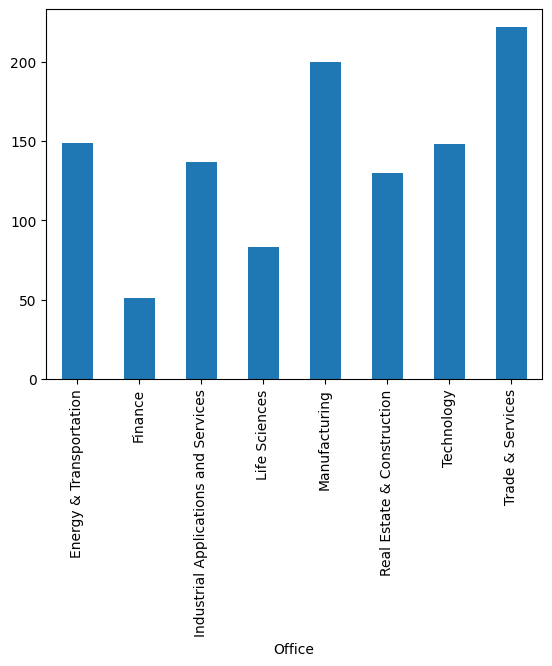

In [6]:
# Plot a bar chart of each office count
import matplotlib.pyplot as plt
data_df.groupby('Office')['ticker'].nunique().plot(kind='bar')

plt.show()

In [7]:
# Drop columns that we don't need at the moment
# We aren't going to drop the leakage columns until right before modeling step
drop_cols1 = ['Stock Splits', 'Dividends']

engineer_df = data_df.copy()
engineer_df = pd.DataFrame(engineer_df.drop(columns=drop_cols1))

engineer_df.columns

Index(['CurrentPeriodDate', 'ticker', 'name', 'sic', 'Office',
       'TopLineRevenue', 'OperatingIncomeLoss', 'NetIncomeLoss',
       'EarningsPerShareDiluted', 'CashAndCashEquivalentsAtCarryingValue',
       'StockholdersEquity', 'CurrentPrice', 'Volume', 'FuturePeriodDate',
       'PeriodLength', 'FuturePeriodPrice', 'LogReturn', 'AvgMonthlyLogReturn',
       'BuySell'],
      dtype='object')

In [8]:
# Check the median of AvgMonthlyLogReturn

engineer_df['AvgMonthlyLogReturn'].median()

0.0064204942829369505

In [9]:
# Update BuySell to be binary 1 = buy for AvgMonthlyLogReturn > 0.0064, 0 = sell for AvgMonthlyLogReturn < 0.0064
engineer_df['BuySell'] = engineer_df['AvgMonthlyLogReturn'].apply(lambda x: 1 if x > 0.0064 else 0)

# Check the distribution of BuySell
engineer_df['BuySell'].value_counts()

BuySell
0    20415
1    20324
Name: count, dtype: int64

In [10]:
# Create the model_df which drops the leakage columns

model_df = engineer_df.copy()

drop_cols2 = ['FuturePeriodDate', 'FuturePeriodPrice', 'PeriodLength','LogReturn', 'AvgMonthlyLogReturn']
model_df = model_df.drop(columns=drop_cols2)
model_df.columns

Index(['CurrentPeriodDate', 'ticker', 'name', 'sic', 'Office',
       'TopLineRevenue', 'OperatingIncomeLoss', 'NetIncomeLoss',
       'EarningsPerShareDiluted', 'CashAndCashEquivalentsAtCarryingValue',
       'StockholdersEquity', 'CurrentPrice', 'Volume', 'BuySell'],
      dtype='object')

In [11]:
### LOGISTIC REGRESSION TEST ###

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

logreg_df = model_df.copy()
logreg_df = logreg_df.sort_values(by=['CurrentPeriodDate','ticker'])


### SET UP THE train_val_test SPLIT ###
# Determine the split point
train_size = int(len(logreg_df) * 0.6)

# Split the data
train_df = logreg_df[:train_size]
temp_df = logreg_df[train_size:]

test_size = int(len(temp_df) * 0.5)

val_df = temp_df[:test_size]
test_df = temp_df[test_size:]


### ENCODE THE TICKER NIL ENCODING ###
# Compute the average NetIncomeLoss per ticker in the training set only
ticker_avg = train_df.groupby('ticker')['NetIncomeLoss'].mean()

# Apply encoding to training data
train_df.loc[:, 'ticker_encoded'] = train_df['ticker'].map(ticker_avg)

# Apply encoding to val and test data using only values from the training set
val_df.loc[:, 'ticker_encoded'] = val_df['ticker'].map(ticker_avg)
test_df.loc[:, 'ticker_encoded'] = test_df['ticker'].map(ticker_avg)

# Handle unseen tickers in test data by filling with the global mean NetIncomeLoss
global_avg = train_df['NetIncomeLoss'].mean()
val_df.loc[:, 'ticker_encoded'].fillna(global_avg, inplace=True)
test_df.loc[:, 'ticker_encoded'].fillna(global_avg, inplace=True)


### SET UP THE MODEL FOR TRAINING ###
target = 'BuySell'

# Drop non-numeric cols (Optional: keep 'Office')
X_train = train_df.drop(columns=[target,'ticker','name','Office'])
y_train = train_df[target]
X_val = val_df.drop(columns=[target,'ticker','name','Office'])
y_val = val_df[target]
X_test = test_df.drop(columns=[target,'ticker','name','Office'])
y_test = test_df[target]

# One-hot encode categorical variables if necessary
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)

# Align the columns of validation and test sets with the training set
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### TESTING THE MODEL ###
# Define the Logistic Regression model
logreg = LogisticRegression(max_iter=1000, random_state=1234)

# Fit the model on the training data
logreg.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred = logreg.predict(X_val)
y_val_pred_proba = logreg.predict_proba(X_val)[:, 1]

# Calculate the F1 score
f1 = f1_score(y_val, y_val_pred)
print(f"F1 Score: {f1:.4f}")

C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\1234805238.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.loc[:, 'ticker_encoded'] = train_df['ticker'].map(ticker_avg)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\1234805238.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df.loc[:, 'ticker_encoded'] = val_df['ticker'].map(ticker_avg)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\1234805238.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

F1 Score: 0.4820


0.4820 F1 score is a great start

In [12]:
### DECISION TREE TEST ###

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

dt_df = model_df.copy()
dt_df = dt_df.sort_values(by=['CurrentPeriodDate','ticker'])


### SET UP THE train_val_test SPLIT ###
# Determine the split point
train_size = int(len(dt_df) * 0.6)

# Split the data
train_df = dt_df[:train_size]
temp_df = dt_df[train_size:]

test_size = int(len(temp_df) * 0.5)

val_df = temp_df[:test_size]
test_df = temp_df[test_size:]


### ENCODE THE TICKER NIL ENCODING ###
# Compute the average NetIncomeLoss per ticker in the training set only
ticker_avg = train_df.groupby('ticker')['NetIncomeLoss'].mean()

# Apply encoding to training data
train_df.loc[:, 'ticker_encoded'] = train_df['ticker'].map(ticker_avg)

# Apply encoding to val and test data using only values from the training set
val_df.loc[:, 'ticker_encoded'] = val_df['ticker'].map(ticker_avg)
test_df.loc[:, 'ticker_encoded'] = test_df['ticker'].map(ticker_avg)

# Handle unseen tickers in test data by filling with the global mean NetIncomeLoss
global_avg = train_df['NetIncomeLoss'].mean()
val_df.loc[:, 'ticker_encoded'].fillna(global_avg, inplace=True)
test_df.loc[:, 'ticker_encoded'].fillna(global_avg, inplace=True)


### SET UP THE MODEL FOR TRAINING ###
target = 'BuySell'

# Drop non-numeric cols (Optional: keep 'Office')
X_train = train_df.drop(columns=[target,'ticker','name','Office'])
y_train = train_df[target]
X_val = val_df.drop(columns=[target,'ticker','name','Office'])
y_val = val_df[target]
X_test = test_df.drop(columns=[target,'ticker','name','Office'])
y_test = test_df[target]

# One-hot encode categorical variables if necessary
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)

# Align the columns of validation and test sets with the training set
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### TESTING THE MODEL ###
# Define the Logistic Regression model
dt = DecisionTreeClassifier(random_state=1234)

# Fit the model on the training data
dt.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred = dt.predict(X_val)
y_val_pred_proba = dt.predict_proba(X_val)[:, 1]

# Calculate the F1 score
f1 = f1_score(y_val, y_val_pred)
print(f"F1 Score: {f1:.4f}")

C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\2382883703.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.loc[:, 'ticker_encoded'] = train_df['ticker'].map(ticker_avg)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\2382883703.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df.loc[:, 'ticker_encoded'] = val_df['ticker'].map(ticker_avg)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\2382883703.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

F1 Score: 0.5591


0.5591 F1 score is EVEN BETTER

In [13]:
### RANDOM FOREST TEST ###

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

rf_df = model_df.copy()
rf_df = rf_df.sort_values(by=['CurrentPeriodDate','ticker'])


### SET UP THE train_val_test SPLIT ###
# Determine the split point
train_size = int(len(rf_df) * 0.6)

# Split the data
train_df = rf_df[:train_size]
temp_df = rf_df[train_size:]

test_size = int(len(temp_df) * 0.5)

val_df = temp_df[:test_size]
test_df = temp_df[test_size:]


### ENCODE THE TICKER NIL ENCODING ###
# Compute the average NetIncomeLoss per ticker in the training set only
ticker_avg = train_df.groupby('ticker')['NetIncomeLoss'].mean()

# Apply encoding to training data
train_df.loc[:, 'ticker_encoded'] = train_df['ticker'].map(ticker_avg)

# Apply encoding to val and test data using only values from the training set
val_df.loc[:, 'ticker_encoded'] = val_df['ticker'].map(ticker_avg)
test_df.loc[:, 'ticker_encoded'] = test_df['ticker'].map(ticker_avg)

# Handle unseen tickers in test data by filling with the global mean NetIncomeLoss
global_avg = train_df['NetIncomeLoss'].mean()
val_df.loc[:, 'ticker_encoded'].fillna(global_avg, inplace=True)
test_df.loc[:, 'ticker_encoded'].fillna(global_avg, inplace=True)


### SET UP THE MODEL FOR TRAINING ###
target = 'BuySell'

# Drop non-numeric cols (Optional: keep 'Office')
X_train = train_df.drop(columns=[target,'ticker','name','Office'])
y_train = train_df[target]
X_val = val_df.drop(columns=[target,'ticker','name','Office'])
y_val = val_df[target]
X_test = test_df.drop(columns=[target,'ticker','name','Office'])
y_test = test_df[target]

# One-hot encode categorical variables if necessary
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)

# Align the columns of validation and test sets with the training set
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### TESTING THE MODEL ###
# Define the Logistic Regression model
rf = RandomForestClassifier(random_state=1234)

# Fit the model on the training data
rf.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred = rf.predict(X_val)
y_val_pred_proba = rf.predict_proba(X_val)[:, 1]

# Calculate the F1 score
f1 = f1_score(y_val, y_val_pred)
print(f"F1 Score: {f1:.4f}")

C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\1363776423.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.loc[:, 'ticker_encoded'] = train_df['ticker'].map(ticker_avg)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\1363776423.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df.loc[:, 'ticker_encoded'] = val_df['ticker'].map(ticker_avg)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\1363776423.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

F1 Score: 0.6014


0.6014 F1 score is EVEN EVEN BETTERRR

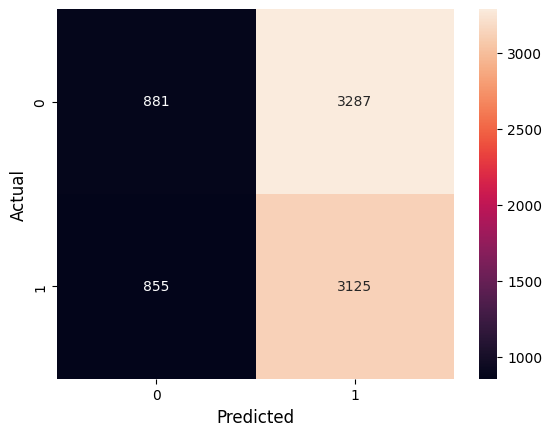

In [14]:
# Visualize the prediction matrix for RF
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

In [15]:
### XGBOOST TEST ###

from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

xgb_df = model_df.copy()
xgb_df = xgb_df.sort_values(by=['CurrentPeriodDate','ticker'])


### SET UP THE train_val_test SPLIT ###
# Determine the split point
train_size = int(len(xgb_df) * 0.6)

# Split the data
train_df = xgb_df[:train_size]
temp_df = xgb_df[train_size:]

test_size = int(len(temp_df) * 0.5)

val_df = temp_df[:test_size]
test_df = temp_df[test_size:]


### ENCODE THE TICKER NIL ENCODING ###
# Compute the average NetIncomeLoss per ticker in the training set only
ticker_avg = train_df.groupby('ticker')['NetIncomeLoss'].mean()

# Apply encoding to training data
train_df.loc[:, 'ticker_encoded'] = train_df['ticker'].map(ticker_avg)

# Apply encoding to val and test data using only values from the training set
val_df.loc[:, 'ticker_encoded'] = val_df['ticker'].map(ticker_avg)
test_df.loc[:, 'ticker_encoded'] = test_df['ticker'].map(ticker_avg)

# Handle unseen tickers in test data by filling with the global mean NetIncomeLoss
global_avg = train_df['NetIncomeLoss'].mean()
val_df.loc[:, 'ticker_encoded'].fillna(global_avg, inplace=True)
test_df.loc[:, 'ticker_encoded'].fillna(global_avg, inplace=True)


### SET UP THE MODEL FOR TRAINING ###
target = 'BuySell'

# Drop non-numeric cols (Optional: keep 'Office')
X_train = train_df.drop(columns=[target,'ticker','name','Office'])
y_train = train_df[target]
X_val = val_df.drop(columns=[target,'ticker','name','Office'])
y_val = val_df[target]
X_test = test_df.drop(columns=[target,'ticker','name','Office'])
y_test = test_df[target]

# One-hot encode categorical variables if necessary
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)

# Align the columns of validation and test sets with the training set
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### TESTING THE MODEL ###
# Define the Logistic Regression model
xgb = XGBClassifier(random_state=1234)

# Fit the model on the training data
xgb.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred = xgb.predict(X_val)
y_val_pred_proba = xgb.predict_proba(X_val)[:, 1]

# Calculate the F1 score
f1 = f1_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
print(f"F1 Score: {f1:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")

C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\1801320471.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.loc[:, 'ticker_encoded'] = train_df['ticker'].map(ticker_avg)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\1801320471.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df.loc[:, 'ticker_encoded'] = val_df['ticker'].map(ticker_avg)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\1801320471.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

F1 Score: 0.5950
Precision Score: 0.4873
Recall Score: 0.7641


0.595 is slightly worse than RF on un-engineered data

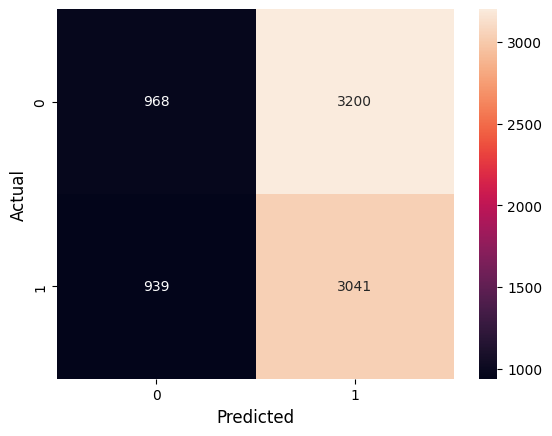

In [16]:
# Visualize the prediction matrix for XGBoost
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

# Let's move forward using XGBoost as our model since it performed basically just as good as RF

In [17]:
# Add financial ratio variables

ratio_df = model_df.copy()

ratio_df['PE_ratio'] = ratio_df['CurrentPrice'] / ratio_df['EarningsPerShareDiluted']
ratio_df['profit_margin'] = ratio_df['NetIncomeLoss'] / ratio_df['TopLineRevenue']
ratio_df['ROE'] = ratio_df['NetIncomeLoss'] / ratio_df['StockholdersEquity']


# Replace infinite values with 0
ratio_df.replace([float('inf'), float('-inf')], 0, inplace=True)

In [18]:
### XGBOOST TEST ###

from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

xgb_df = ratio_df.copy()
xgb_df = xgb_df.sort_values(by=['CurrentPeriodDate','ticker'])


### SET UP THE train_val_test SPLIT ###
# Determine the split point
train_size = int(len(xgb_df) * 0.6)

# Split the data
train_df = xgb_df[:train_size]
temp_df = xgb_df[train_size:]

test_size = int(len(temp_df) * 0.5)

val_df = temp_df[:test_size]
test_df = temp_df[test_size:]


### ENCODE THE TICKER NIL ENCODING ###
# Compute the average NetIncomeLoss per ticker in the training set only
ticker_avg = train_df.groupby('ticker')['NetIncomeLoss'].mean()

# Apply encoding to training data
train_df.loc[:, 'ticker_encoded'] = train_df['ticker'].map(ticker_avg)

# Apply encoding to val and test data using only values from the training set
val_df.loc[:, 'ticker_encoded'] = val_df['ticker'].map(ticker_avg)
test_df.loc[:, 'ticker_encoded'] = test_df['ticker'].map(ticker_avg)

# Handle unseen tickers in test data by filling with the global mean NetIncomeLoss
global_avg = train_df['NetIncomeLoss'].mean()
val_df.loc[:, 'ticker_encoded'].fillna(global_avg, inplace=True)
test_df.loc[:, 'ticker_encoded'].fillna(global_avg, inplace=True)


### SET UP THE MODEL FOR TRAINING ###
target = 'BuySell'

# Drop non-numeric cols (Optional: keep 'Office')
X_train = train_df.drop(columns=[target,'ticker','name','Office'])
y_train = train_df[target]
X_val = val_df.drop(columns=[target,'ticker','name','Office'])
y_val = val_df[target]
X_test = test_df.drop(columns=[target,'ticker','name','Office'])
y_test = test_df[target]

# One-hot encode categorical variables if necessary
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)

# Align the columns of validation and test sets with the training set
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### TESTING THE MODEL ###
# Define the Logistic Regression model
xgb = XGBClassifier(random_state=1234)

# Fit the model on the training data
xgb.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred = xgb.predict(X_val)
y_val_pred_proba = xgb.predict_proba(X_val)[:, 1]

# Calculate the F1 score
f1 = f1_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
print(f"F1 Score: {f1:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")


C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\3922945602.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.loc[:, 'ticker_encoded'] = train_df['ticker'].map(ticker_avg)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\3922945602.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df.loc[:, 'ticker_encoded'] = val_df['ticker'].map(ticker_avg)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\3922945602.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

F1 Score: 0.6091
Precision Score: 0.4854
Recall Score: 0.8176


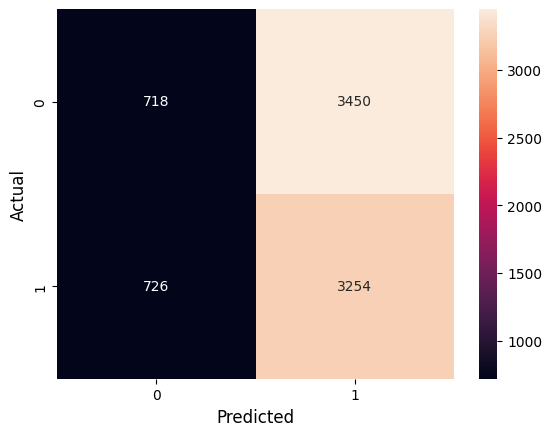

In [19]:
# Visualize the prediction matrix for XGBoost
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

In [20]:
ratio_df.columns

Index(['CurrentPeriodDate', 'ticker', 'name', 'sic', 'Office',
       'TopLineRevenue', 'OperatingIncomeLoss', 'NetIncomeLoss',
       'EarningsPerShareDiluted', 'CashAndCashEquivalentsAtCarryingValue',
       'StockholdersEquity', 'CurrentPrice', 'Volume', 'BuySell', 'PE_ratio',
       'profit_margin', 'ROE'],
      dtype='object')

In [21]:
# Add vs_prior variables

delta_df = ratio_df.copy()
delta_df = delta_df.sort_values(by=['CurrentPeriodDate','ticker'])

delta_df.head(5)

numeric_features = ('TopLineRevenue', 'OperatingIncomeLoss', 'NetIncomeLoss',
       'EarningsPerShareDiluted', 'CashAndCashEquivalentsAtCarryingValue',
       'StockholdersEquity', 'CurrentPrice', 'Volume','PE_ratio','profit_margin', 'ROE')

for feature in numeric_features:
    delta_df[f"{feature}_vs_prior"] = delta_df.groupby('ticker')[f"{feature}"].diff()

delta_df.head(5)

,CurrentPeriodDate,ticker,name,sic,Office,TopLineRevenue,OperatingIncomeLoss,NetIncomeLoss,EarningsPerShareDiluted,CashAndCashEquivalentsAtCarryingValue,...,OperatingIncomeLoss_vs_prior,NetIncomeLoss_vs_prior,EarningsPerShareDiluted_vs_prior,CashAndCashEquivalentsAtCarryingValue_vs_prior,StockholdersEquity_vs_prior,CurrentPrice_vs_prior,Volume_vs_prior,PE_ratio_vs_prior,profit_margin_vs_prior,ROE_vs_prior
0,201001,COST,COSTCO WHOLESALE CORP /NEW,5331.0,Trade & Services,1.874200e+10,4.700000e+08,2.990000e+08,0.67,4.134000e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,201001,CRM,SALESFORCE COM INC,7372.0,Technology,3.540490e+08,2.551900e+07,2.039400e+07,0.16,1.011306e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,201001,HPQ,HEWLETT PACKARD CO,3570.0,Technology,3.117700e+10,3.003000e+09,2.250000e+09,0.93,1.354700e+10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,201001,HRB,H&R BLOCK INC,7200.0,Trade & Services,9.348520e+08,9.444400e+07,5.063500e+07,0.15,1.727677e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,201002,ADBE,ADOBE SYSTEMS INC,7372.0,Technology,8.587000e+08,1.768330e+08,1.271540e+08,0.24,1.589442e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
### XGBOOST TEST ###

from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

xgb_df = delta_df.copy()
xgb_df = xgb_df.sort_values(by=['CurrentPeriodDate','ticker'])


### SET UP THE train_val_test SPLIT ###
# Determine the split point
train_size = int(len(xgb_df) * 0.6)

# Split the data
train_df = xgb_df[:train_size]
temp_df = xgb_df[train_size:]

test_size = int(len(temp_df) * 0.5)

val_df = temp_df[:test_size]
test_df = temp_df[test_size:]


### ENCODE THE TICKER NIL ENCODING ###
# Compute the average NetIncomeLoss per ticker in the training set only
ticker_avg = train_df.groupby('ticker')['NetIncomeLoss'].mean()

# Apply encoding to training data
train_df.loc[:, 'ticker_encoded'] = train_df['ticker'].map(ticker_avg)

# Apply encoding to val and test data using only values from the training set
val_df.loc[:, 'ticker_encoded'] = val_df['ticker'].map(ticker_avg)
test_df.loc[:, 'ticker_encoded'] = test_df['ticker'].map(ticker_avg)

# Handle unseen tickers in test data by filling with the global mean NetIncomeLoss
global_avg = train_df['NetIncomeLoss'].mean()
val_df.loc[:, 'ticker_encoded'].fillna(global_avg, inplace=True)
test_df.loc[:, 'ticker_encoded'].fillna(global_avg, inplace=True)


### SET UP THE MODEL FOR TRAINING ###
target = 'BuySell'

# Drop non-numeric cols (Optional: keep 'Office')
X_train = train_df.drop(columns=[target,'ticker','name','Office'])
y_train = train_df[target]
X_val = val_df.drop(columns=[target,'ticker','name','Office'])
y_val = val_df[target]
X_test = test_df.drop(columns=[target,'ticker','name','Office'])
y_test = test_df[target]

# One-hot encode categorical variables if necessary
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)

# Align the columns of validation and test sets with the training set
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### TESTING THE MODEL ###
# Define the Logistic Regression model
xgb = XGBClassifier(random_state=1234)

# Fit the model on the training data
xgb.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred = xgb.predict(X_val)
y_val_pred_proba = xgb.predict_proba(X_val)[:, 1]

# Calculate the F1 score
f1 = f1_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
print(f"F1 Score: {f1:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")


C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\1215765135.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.loc[:, 'ticker_encoded'] = train_df['ticker'].map(ticker_avg)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\1215765135.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df.loc[:, 'ticker_encoded'] = val_df['ticker'].map(ticker_avg)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\1215765135.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

F1 Score: 0.6133
Precision Score: 0.5006
Recall Score: 0.7915


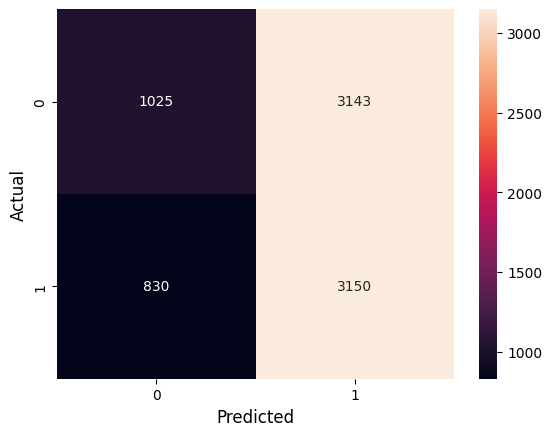

In [23]:
# Visualize the prediction matrix for XGBoost
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

# Approach 2: Iterative Predicting

Predict only the values of the next date. Retrain the model on the predicted value, and so on

In [24]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

# Assume data is already sorted by ['CurrentPeriodDate', 'ticker']
dates = xgb_df['CurrentPeriodDate'].unique()
results = []

# Start walk-forward loop from the N-th date to ensure enough training data
for i in range(5, len(dates) - 1):
    train_dates = dates[:i]
    test_date = dates[i]

    # Train data: all previous dates
    train_df = xgb_df[xgb_df['CurrentPeriodDate'].isin(train_dates)].copy()
    test_df = xgb_df[xgb_df['CurrentPeriodDate'] == test_date].copy()

    # Ticker encoding from training data
    ticker_avg = train_df.groupby('ticker')['NetIncomeLoss'].mean()
    global_avg = train_df['NetIncomeLoss'].mean()

    for df in [train_df, test_df]:
        df['ticker_encoded'] = df['ticker'].map(ticker_avg)
        df['ticker_encoded'].fillna(global_avg, inplace=True)

    # Features + target
    target = 'BuySell'
    drop_cols = ['ticker', 'name', 'Office', target]
    X_train = pd.get_dummies(train_df.drop(columns=drop_cols))
    y_train = train_df[target]
    X_test = pd.get_dummies(test_df.drop(columns=drop_cols))
    y_test = test_df[target]

    # Align columns
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    # Train model
    model = XGBClassifier(random_state=1234)
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    f1 = f1_score(y_test, y_pred, zero_division=0)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)

    results.append({
        'date': test_date,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'n_samples': len(test_df)
    })

# Results DataFrame
results_df = pd.DataFrame(results)
print(results_df)
print("Average F1:", results_df['f1'].mean())


C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\258105005.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ticker_encoded'].fillna(global_avg, inplace=True)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\258105005.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

       date        f1  precision    recall  n_samples
0    201006  0.523490   0.764706  0.397959        136
1    201007  0.888889   1.000000  0.800000         11
2    201008  0.888889   0.888889  0.888889         10
3    201009  0.845188   0.759398  0.952830        139
4    201010  0.705882   0.600000  0.857143         11
..      ...       ...        ...       ...        ...
166  202404  0.689655   0.545455  0.937500         64
167  202405  0.555556   0.526316  0.588235         28
168  202406  0.491228   0.388889  0.666667        865
169  202407  0.509804   0.619048  0.433333         54
170  202408  0.285714   0.333333  0.250000          9

[171 rows x 5 columns]
Average F1: 0.5319186220647965


In [25]:
# Compute weighted F1 average
weighted_f1 = (results_df['f1'] * results_df['n_samples']).sum() / results_df['n_samples'].sum()
print(f"Weighted Average F1: {weighted_f1:.4f}")


Weighted Average F1: 0.5047


In [26]:
from sklearn.metrics import confusion_matrix

# Initialize counters
tp_total = 0
fp_total = 0
tn_total = 0
fn_total = 0

# For loop iterates through each date in the "test" set
# Calculates the confusion matrix for each date and accumulates totals
for i in range(int(len(dates)*0.6), len(dates) - 1): # 60% train, 40% test
    train_dates = dates[:i]
    test_date = dates[i]

    # Train data: all previous dates
    train_df = xgb_df[xgb_df['CurrentPeriodDate'].isin(train_dates)].copy()
    test_df = xgb_df[xgb_df['CurrentPeriodDate'] == test_date].copy()

    # Ticker encoding from training data
    ticker_avg = train_df.groupby('ticker')['NetIncomeLoss'].mean()
    global_avg = train_df['NetIncomeLoss'].mean()

    for df in [train_df, test_df]:
        df['ticker_encoded'] = df['ticker'].map(ticker_avg)
        df['ticker_encoded'].fillna(global_avg, inplace=True)

    # Features + target
    target = 'BuySell'
    drop_cols = ['ticker', 'name', 'Office', target]
    X_train = pd.get_dummies(train_df.drop(columns=drop_cols))
    y_train = train_df[target]
    X_test = pd.get_dummies(test_df.drop(columns=drop_cols))
    y_test = test_df[target]

    # Align columns
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    # Train model
    model = XGBClassifier(random_state=1234)
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()

    # Accumulate totals
    tp_total += tp
    fp_total += fp
    tn_total += tn
    fn_total += fn

    # Keep date-wise for time-series breakdown
    results.append({
        'date': test_date,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn,
        'n_samples': len(test_df)
    })

# Compute final aggregate metrics
precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) > 0 else 0
recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Aggregate Precision: {precision:.4f}")
print(f"Aggregate Recall: {recall:.4f}")
print(f"Aggregate F1 Score: {f1:.4f}")


C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\810266053.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ticker_encoded'].fillna(global_avg, inplace=True)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_15480\810266053.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

Aggregate Precision: 0.5728
Aggregate Recall: 0.5905
Aggregate F1 Score: 0.5815


In [27]:
print(f"True Positives: {tp_total}")
print(f"False Positives: {fp_total}")
print(f"True Negatives: {tn_total}")
print(f"False Negatives: {fn_total}")

True Positives: 6366
False Positives: 4748
True Negatives: 6584
False Negatives: 4415


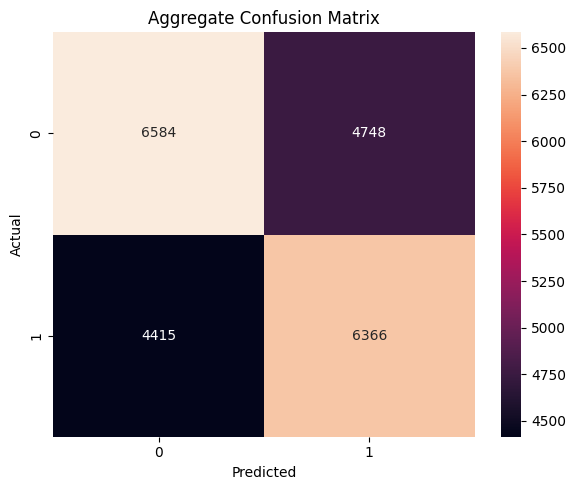

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix in standard format
conf_matrix = np.array([[tn_total, fp_total],
                        [fn_total, tp_total]])

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])

plt.title("Aggregate Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [32]:
# Is AAPL in tickers?
aapl_in_train = 'AAPL' in train_df['ticker'].values

aapl_in_train

True